# Practice Session

# Loan Prepayment Analysis using Pandas & Plotly

In this exercise we will analyze **how loan prepayments reduce interest and loan tenure**.

We will compare different scenarios:

1️⃣ Regular EMI (No prepayment)
2️⃣ Monthly extra payment ₹1000
3️⃣ Yearly prepayment ₹50,000
4️⃣ Tax refund prepayment
5️⃣ Bonus / performance pay prepayment
6️⃣ Mutual fund lock-in maturity prepayment

We will visualize **how much money and time we save**.

---



In [1]:
# !pip install pandas plotly

In [2]:
# Import Libraries
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

### Loan Details

Example loan:

| Parameter     | Value      |
| ------------- | ---------- |
| Loan Amount   | ₹30,00,000 |
| Interest Rate | 9.5%       |
| Tenure        | 30 years   |

In [3]:
k = 1000
lakh = 100 * k
loan_amount = 30 * lakh
annual_rate = 9.5
years = 30

monthly_rate = annual_rate / 12 / 100
months = years * 12

In [4]:
# Calculate EMI
emi = loan_amount * monthly_rate * (1 + monthly_rate)**months / ((1 + monthly_rate)**months - 1)

print("Monthly EMI:", round(emi))

Monthly EMI: 25226


In [5]:
# Create EMI Schedule with Pandas
balance = loan_amount

schedule = []

for month in range(1, months + 1):

    interest = balance * monthly_rate
    principal = emi - interest

    balance -= principal

    schedule.append([month, principal, interest, balance])

df = pd.DataFrame(schedule, columns=[
    "Month",
    "Principal",
    "Interest",
    "Balance"
])

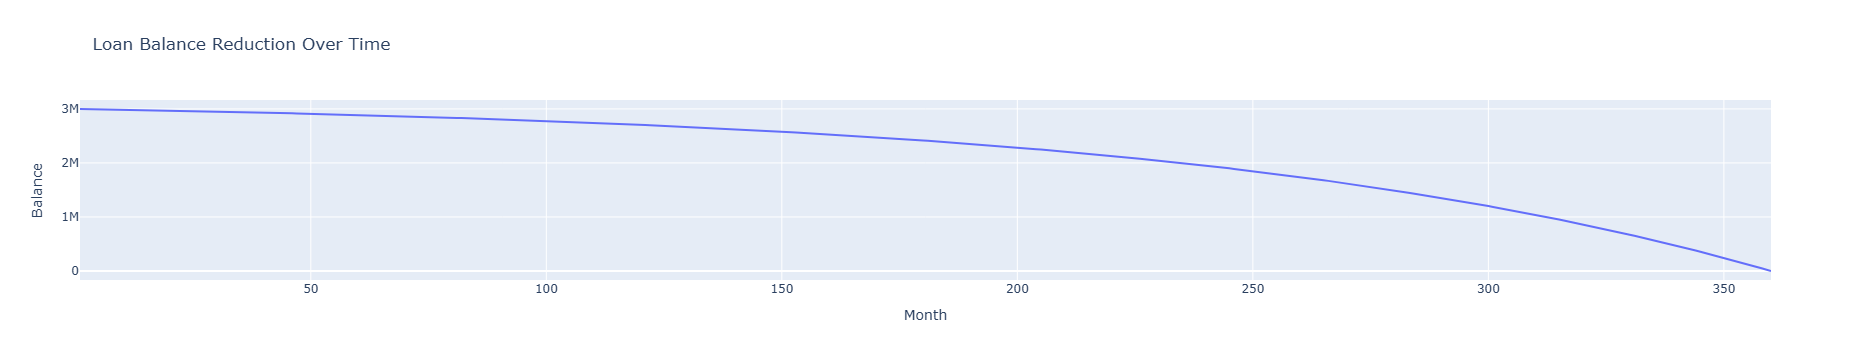

In [6]:
# Plot 1 – Loan Balance Over Time
fig = px.line(
    df,
    x="Month",
    y="Balance",
    title="Loan Balance Reduction Over Time"
)

fig.show()

We can see **how slowly principal reduces initially**.

Most early EMI goes to **interest**.

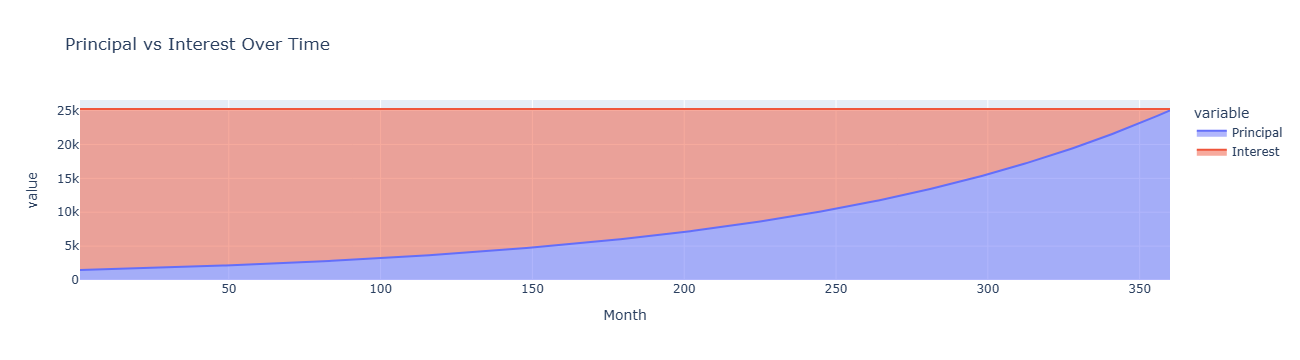

In [7]:
# Plot – Interest vs Principal
fig = px.area(
    df,
    x="Month",
    y=["Principal", "Interest"],
    title="Principal vs Interest Over Time"
)

fig.show()

Early years → **mostly interest**

Later years → **mostly principal**

In [8]:
# Scenario 1 – Monthly Prepayment ₹1000
extra = 1 * k
balance = loan_amount

schedule2 = []

for month in range(1, months + 1):

    interest = balance * monthly_rate
    principal = emi - interest + extra

    balance -= principal

    if balance <= 0:
        break

    schedule2.append([month, balance])

df_extra = pd.DataFrame(schedule2, columns=["Month","Balance"])
df_extra

,Month,Balance
0,1,2.997524e+06
1,2,2.995029e+06
2,3,2.992514e+06
3,4,2.989979e+06
4,5,2.987424e+06
...,...,...
294,295,1.108121e+05
295,296,8.546371e+04
296,297,5.991467e+04
297,298,3.416337e+04


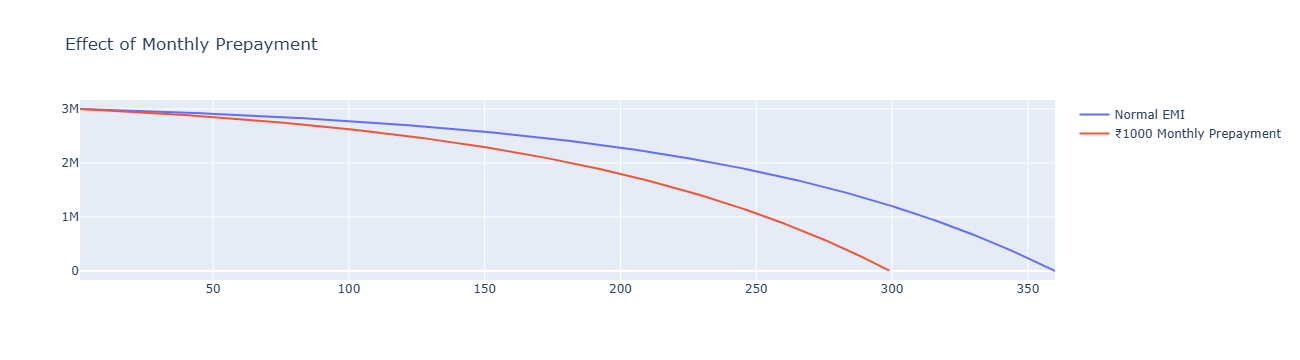

In [9]:
# Plot 3 – EMI vs Monthly Prepayment
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["Month"],
    y=df["Balance"],
    name="Normal EMI"
))

fig.add_trace(go.Scatter(
    x=df_extra["Month"],
    y=df_extra["Balance"],
    name="₹1000 Monthly Prepayment"
))

fig.update_layout(title="Effect of Monthly Prepayment")

fig.show()

Even **₹1000 extra per month** drastically reduces loan tenure.

In [10]:
# Scenario 2 – Yearly Prepayment ₹50,000

yearly_prepay = 50 * k
balance = loan_amount

schedule3 = []

for month in range(1, months + 1):

    interest = balance * monthly_rate
    principal = emi - interest

    balance -= principal

    if month % 12 == 0:
        balance -= yearly_prepay

    schedule3.append([month, balance])

df_yearly = pd.DataFrame(schedule3, columns=["Month","Balance"])

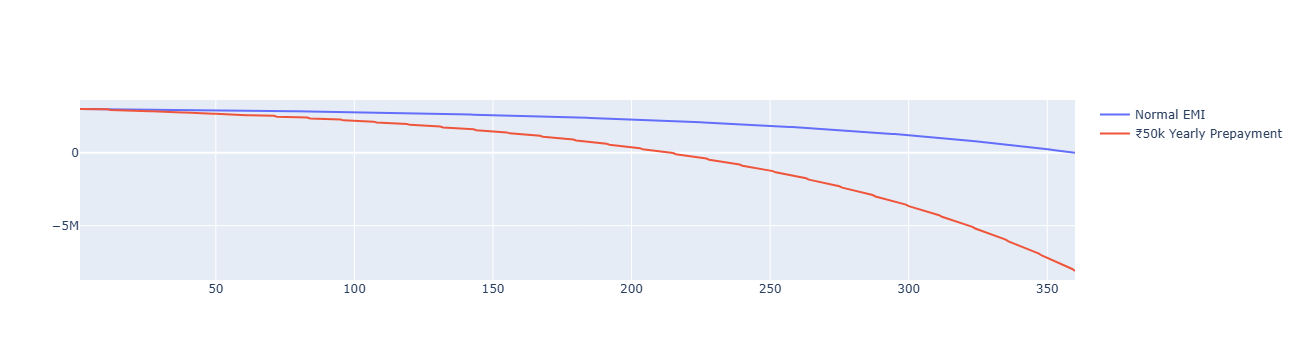

In [11]:
# Plot 4 – Yearly Prepayment Effect
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["Month"],
    y=df["Balance"],
    name="Normal EMI"
))

fig.add_trace(go.Scatter(
    x=df_yearly["Month"],
    y=df_yearly["Balance"],
    name="₹50k Yearly Prepayment"
))

fig.show()

# Monthly Extra Payment vs Loan Duration

- Now we analyze **how monthly prepayment changes loan tenure**.

In [45]:
extra_range = range(0, 50 * k , 1 * k)

results = []

for extra in extra_range:

    balance = loan_amount
    months_taken = 0

    for i in range(months):

        interest = balance * monthly_rate
        principal = emi - interest

        balance -= principal
        balance -= extra

        months_taken += 1

        if balance <= 0:
            break

    results.append([extra, months_taken])

df_extra = pd.DataFrame(results, columns=["Extra Payment","Months"])

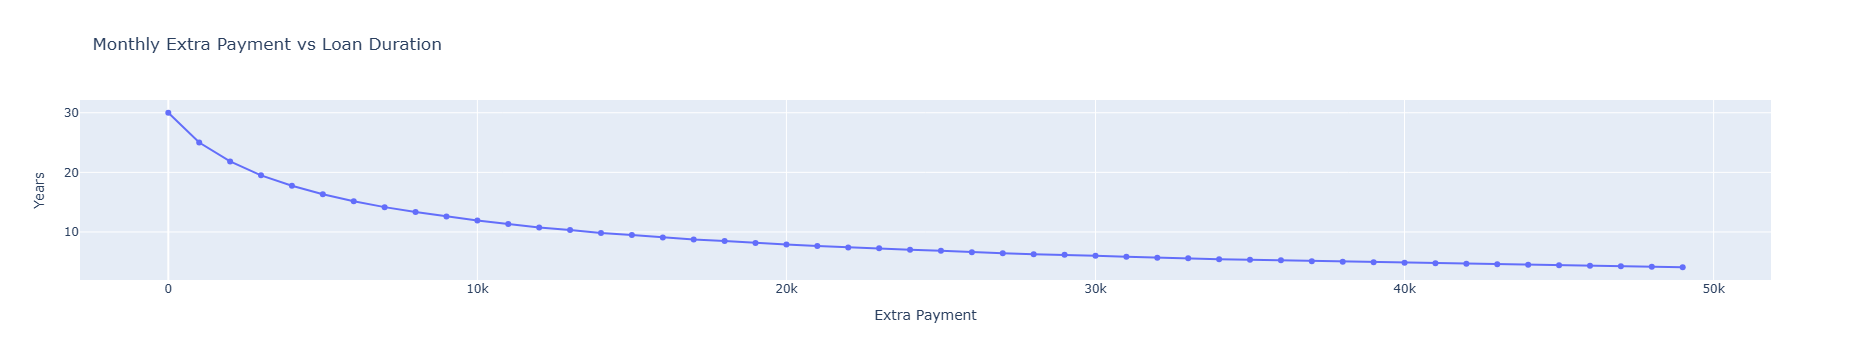

In [46]:
#  Extra Payment vs Years Saved
df_extra["Years"] = df_extra["Months"] / 12

fig = px.line(
    df_extra,
    x="Extra Payment",
    y="Years",
    markers=True,
    title="Monthly Extra Payment vs Loan Duration"
)

fig.show()

Even **₹1000 extra per month** can save **several years**.

In [47]:
# We subtract the current months from the very first 'Months' value
df_extra['Months_Saved'] = df_extra['Months'].diff()

df_extra = df_extra.dropna()

df_extra

,Extra Payment,Months,Years,Months_Saved
1,1000,300,25.000000,-60.0
2,2000,262,21.833333,-38.0
3,3000,234,19.500000,-28.0
4,4000,213,17.750000,-21.0
5,5000,196,16.333333,-17.0
6,6000,182,15.166667,-14.0
7,7000,170,14.166667,-12.0
8,8000,160,13.333333,-10.0
9,9000,151,12.583333,-9.0
10,10000,143,11.916667,-8.0


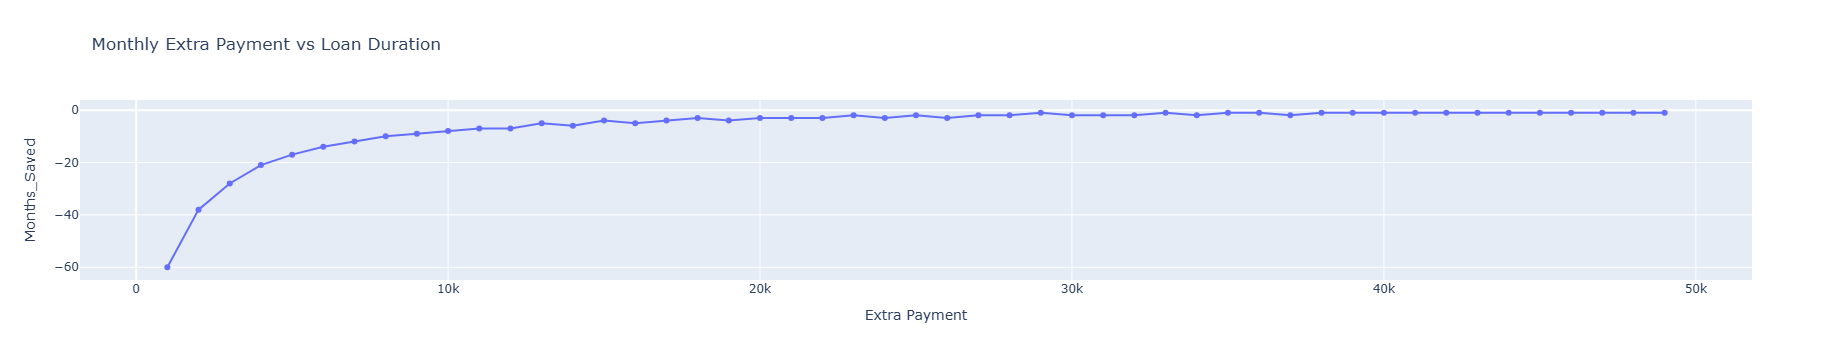

In [48]:

fig = px.line(
    df_extra,
    x="Extra Payment",
    y="Months_Saved",
    markers=True,
    title="Monthly Extra Payment vs Loan Duration"
)

fig.show()

# Prepayment Configuration

In [112]:
balance = loan_amount

annual_payment = 50 * k * 0
income_tax_return = 50 * k
mf_unlocked = 1.5 * lakh * 0

extra_yearly_payment = 20 * k
extra_month_payment = 1 * k * 0

# Loan Simulation Engine

This loop calculates the **loan schedule with all prepayment options**.

In [113]:
schedule = []

balance = loan_amount

for year in range(0, months // 12):

    for month in range(0, 12):

        interest = balance * monthly_rate
        principal_paid = emi - interest

        balance = balance - principal_paid

        # monthly extra payment
        balance = balance - extra_month_payment

        # yearly prepayment
        if month == 3:   # performance bonus
            balance = balance - annual_payment

        if month == 8:   # income tax refund
            balance = balance - income_tax_return

        if month == 4:   # mutual fund maturity
            balance = balance - mf_unlocked

        if month == 0:   # yearly extra payment
            balance = balance - extra_yearly_payment

        schedule.append([year, month, interest, principal_paid, balance])

        if balance <= 0:
            break

    if balance <= 0:
        break

df = pd.DataFrame(
    schedule,
    columns=["Year","Month","Interest","Principal","Balance"]
)
df

,Year,Month,Interest,Principal,Balance
0,0,0,23750.000000,1475.626215,2.978524e+06
1,0,1,23579.984626,1645.641590,2.976879e+06
2,0,2,23566.956630,1658.669585,2.975220e+06
3,0,3,23553.825496,1671.800720,2.973548e+06
4,0,4,23540.590407,1685.035809,2.971863e+06
...,...,...,...,...,...
179,14,11,1060.843714,24164.782502,1.098365e+05
180,15,0,869.539186,24356.087030,6.548044e+04
181,15,1,518.386830,24707.239385,4.077320e+04
182,15,2,322.787851,24902.838364,1.587036e+04


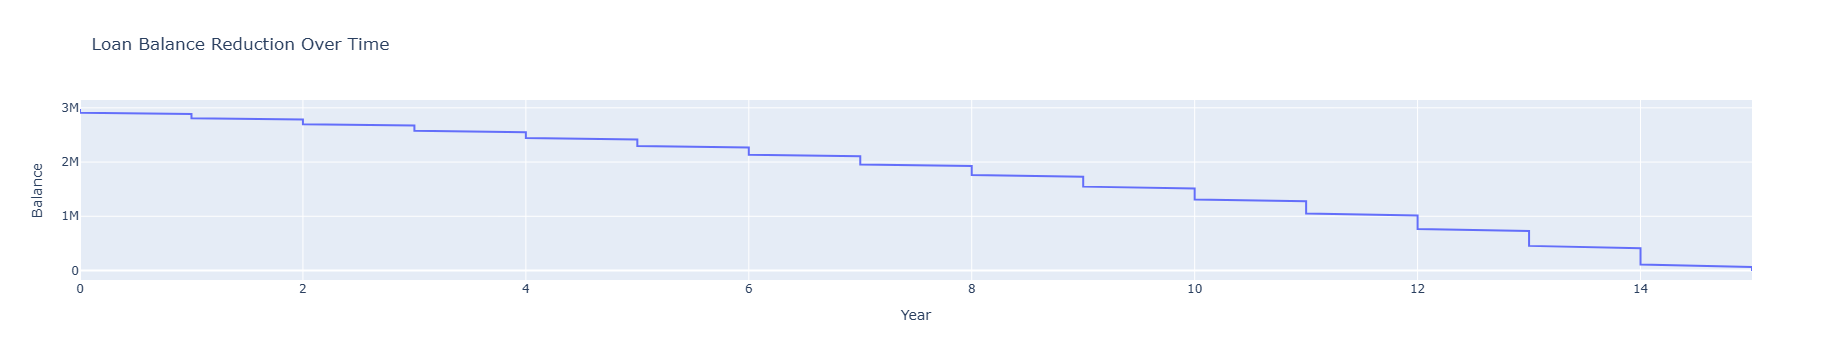

In [114]:
# Loan Balance Over Time
fig = px.line(
    df,
    x="Year", 
    y="Balance",
    title="Loan Balance Reduction Over Time"
)

fig.show()

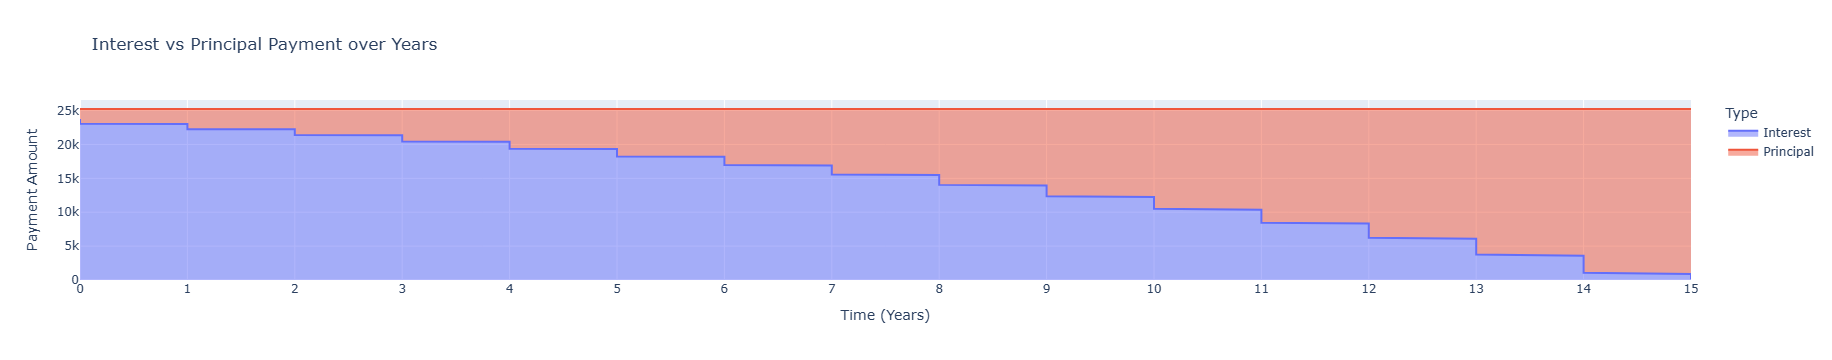

In [115]:
fig = px.area(
    df,
    x="Year", 
    y=["Interest", "Principal"],
    title="Interest vs Principal Payment over Years",
    labels={"Year": "Time (Years)", "value": "Payment Amount", "variable": "Type"}
)

# Optional: Improve x-axis ticks to show whole years
fig.update_xaxes(dtick=1) 

fig.show()